<a href="https://colab.research.google.com/github/LiuChen-5749342/Generative-AI-and-AI-Applications/blob/main/Task_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 17**

The Assignment: You are a Quantitative Analyst. Your boss wants to know which sector has performed better this year on a risk-adjusted basis: Big Tech or Big Banks.

Task: Write a prompt for your Local smolagents (Qwen 3B) agent to perform the following steps autonomously:

Data Ingestion: Download daily closing prices for the last 180 days for a Tech Portfolio (NVDA, AAPL, MSFT) and a Bank Portfolio (JPM, BAC, C).

**Financial Math:**

1. Calculate the Daily Returns for each stock.
2. Calculate the Sharpe Ratio for each stock (Assume risk-free rate = 0, so simply Mean Daily Return / Std Dev of Daily Returns * sqrt(252)).

**Visualization:**

Create a Bar Chart comparing the Sharpe Ratios of all 6 companies.

Color code the bars: Green for Tech, Blue for Banks.

Output: Save the chart as sharpe_comparison.png.

In [1]:
# ==========================================
# Install Dependencies
# ==========================================
# We need 'accelerate' and 'bitsandbytes' to load the model efficiently on the GPU.
# Added 'duckduckgo_search' to enable web search capabilities for the agent.
!pip install -q smolagents transformers accelerate bitsandbytes yfinance seaborn matplotlib duckduckgo_search

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 113.5 MB/s eta 0:00:00


In [2]:
# ==========================================
# Load the 3B Model (Lightweight & Fast)
# ==========================================
from smolagents import CodeAgent, TransformersModel
import torch

print("⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...")

# We use the 3B-Instruct model.
# device_map="auto" finds the Colab GPU.
# torch_dtype=torch.float16 cuts memory usage in half.
model = TransformersModel(
    model_id="Qwen/Qwen2.5-Coder-3B-Instruct",
    device_map="auto",
    torch_dtype=torch.float16,
    max_new_tokens=2048  # Give it space to write longer scripts
)

print("✅ 3B Model loaded on GPU! Ready for coding.")

⬇️ Downloading Qwen 2.5 Coder 3B (approx 6GB)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ 3B Model loaded on GPU! Ready for coding.


In [3]:
# ==========================================
# Initialize the Agent
# ==========================================

# We authorize the agent to use specific data science libraries, and now also a web search library.
agent = CodeAgent(
    tools=[], # We don't need pre-made tools; the agent writes its own code.
    model=model,
    max_steps=3,
    additional_authorized_imports=[
        "yfinance",
        "pandas",
        "numpy",
        "seaborn",
        "matplotlib.pyplot",
        "duckduckgo_search" # Added for web search capabilities
    ]
)

🤖 Agent is coding... (Watch the 'Thought' process below)


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 1. Download daily closing data for 'NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC' and 'C' for the last 180 days using     │
│ yfinance.                                                                                                       │
│ 2. Create a single DataFrame with these close prices.                                                           │
│ 3. Calculate the daily returns according to these close prices.                                                 │
│ 4. Calculate the Sharpe Ratio for each stock (Assume risk-free rate = 0, so simply Mean Daily Return / Std Dev  │
│ of Daily Returns * sqrt(252))                                                                                   │
│ 5. Create a Bar Chart comparing the Sharpe Ratios of all 6 companies.                                           │
│ 6. Color code the bars: Green for 'NVDA' ,'AAPL' and 'MSFT', Blue for 'JPM', 'BAC' and 'C'.                     │
│ 7. Save the chart as 'sharpe_comparison.png'                                                                    │
│                                                                                                                 │
╰─ TransformersModel - Qwen/Qwen2.5-Coder-3B-Instruct ────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Step 1: Download daily closing data for the specified stocks                                                   
  tickers = ['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C']                                                            
  data = yf.download(tickers, period='180d')                                                                       
                                                                                                                   
  # Step 2: Create a single DataFrame with these close prices                                                      
  close_prices = data['Close']                                                                                     
                                                                                                                   
  # Step 3: Calculate the daily returns                                                                            
  daily_returns = close_prices.pct_change()                                                                        
                                                                                                                   
  # Step 4: Calculate the Sharpe Ratio for each stock                                                              
  risk_free_rate = 0                                                                                               
  num_days = len(daily_returns)                                                                                    
  daily_returns = daily_returns.dropna()  # Remove NaN values due to missing data                                  
  sharpe_ratios = daily_returns.mean() / daily_returns.std() * (num_days ** 0.5)                                   
                                                                                                                   
  # Step 5: Create a Bar Chart comparing the Sharpe Ratios of all 6 companies                                      
  colors = {'NVDA': 'green', 'AAPL': 'green', 'MSFT': 'green', 'JPM': 'blue', 'BAC': 'blue', 'C': 'blue'}          
  plt.figure(figsize=(10, 6))                                                                                      
  bars = plt.bar(sharpe_ratios.index, sharpe_ratios.values, color=[colors[ticker] for ticker in                    
  sharpe_ratios.index])                                                                                            
  plt.title('Sharpe Ratios of Stocks')                                                                             
  plt.xlabel('Stock Ticker')                                                                                       
  plt.ylabel('Sharpe Ratio')                                                                                       
  plt.grid(axis='y')                                                                                               
  plt.xticks(rotation=45)                                                                                          
                                                                                                                   
  # Step 6: Save the chart as 'sharpe_comparison.png'                                                              
  plt.savefig('[38;

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  6 of 6 completed


...

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  import yfinance as yf                                                                                            
  import pandas as pd                                                                                              
  import matplotlib.pyplot as plt                                                                                  
                                                                                                                   
  # Step 1: Download daily closing data for the specified stocks                                                   
  tickers = ['NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC', 'C']                                                            
  data = yf.download(tickers, period='180d')                                                                       
                                                                                                                   
  # Step 2: Create a single DataFrame with these close prices                                                      
  close_prices = data['Close']                                                                                     
                                                                                                                   
  # Step 3: Calculate the daily returns                                                                            
  daily_returns = close_prices.pct_change().dropna()  # Drop NaN values due to missing data                        
                                                                                                                   
  # Step 4: Calculate the Sharpe Ratio for each stock                                                              
  risk_free_rate = 0                                                                                               
  num_days = len(daily_returns)                                                                                    
  sharpe_ratios = daily_returns.mean() / daily_returns.std() * (num_days ** 0.5)                                   
                                                                                                                   
  # Step 5: Create a Bar Chart comparing the Sharpe Ratios of all 6 companies                                      
  colors = {'NVDA': 'green', 'AAPL': 'green', 'MSFT': 'green', 'JPM': 'blue', 'BAC': 'blue', 'C': 'blue'}          
  plt.figure(figsize=(10, 6))                                                                                      
  bars = plt.bar(sharpe_ratios.index, sharpe_ratios.values, color=[colors[ticker] for ticker in                    
  sharpe_ratios.index])                                                                                            
  plt.title('Sharpe Ratios of Stocks')                                                                             
  plt.xlabel('Stock Ticker')                                                                                       
  plt.ylabel('Sharpe Ratio')                                                                                       
  plt.grid(axis='y')                                                                                               
  plt.xticks(rotation=45)                                                                                          
                                                                                                                   
  # Step 6: Save the chart as 'sharpe_comparison.png'                                                              
  try:                                                                                                             
      plt.savefig('sharpe_comparison.png[38;2;230;219;1

/usr/local/lib/python3.12/dist-packages/smolagents/local_python_executor.py:918: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return func(*args, **kwargs)
[*********************100%***********************]  6 of 6 completed


Execution logs:
Chart saved successfully as 'sharpe_comparison.png'

Final answer: Chart saved successfully

[Step 3: Duration 83.30 seconds| Input tokens: 9,406 | Output tokens: 2,482]

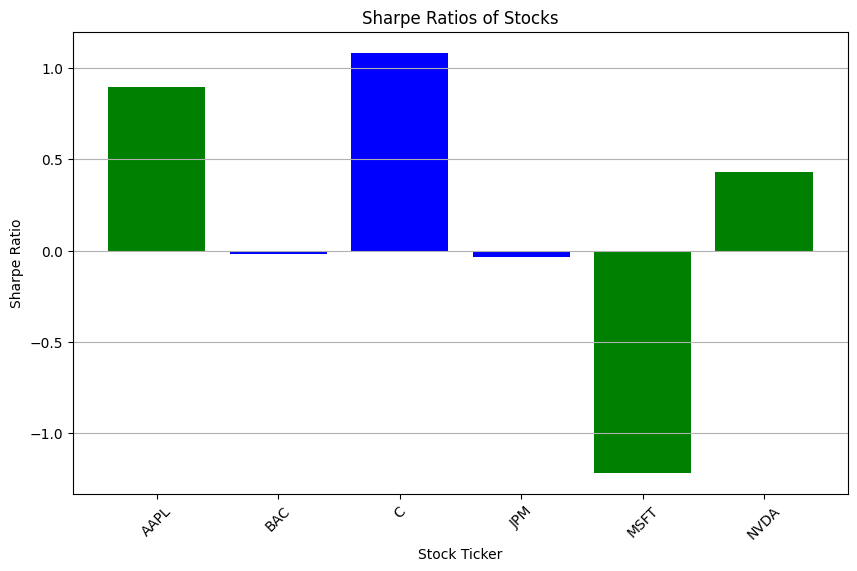

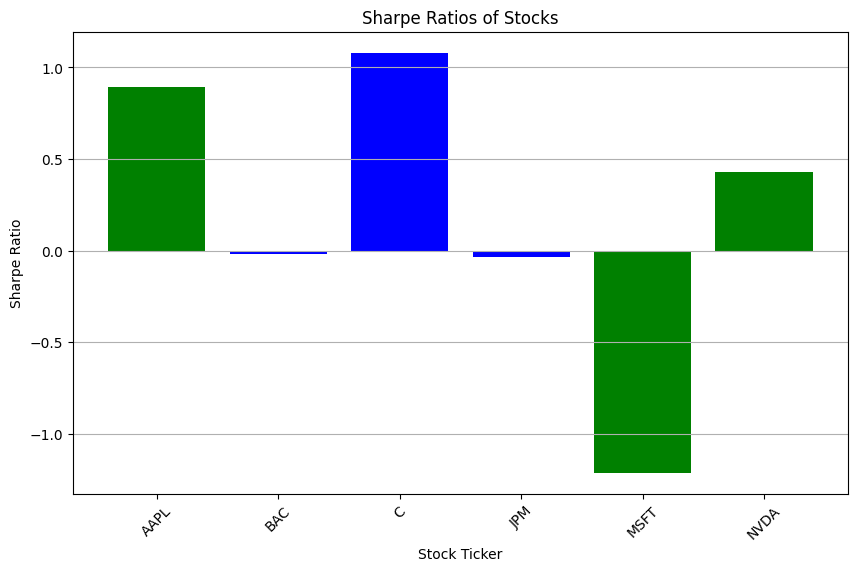

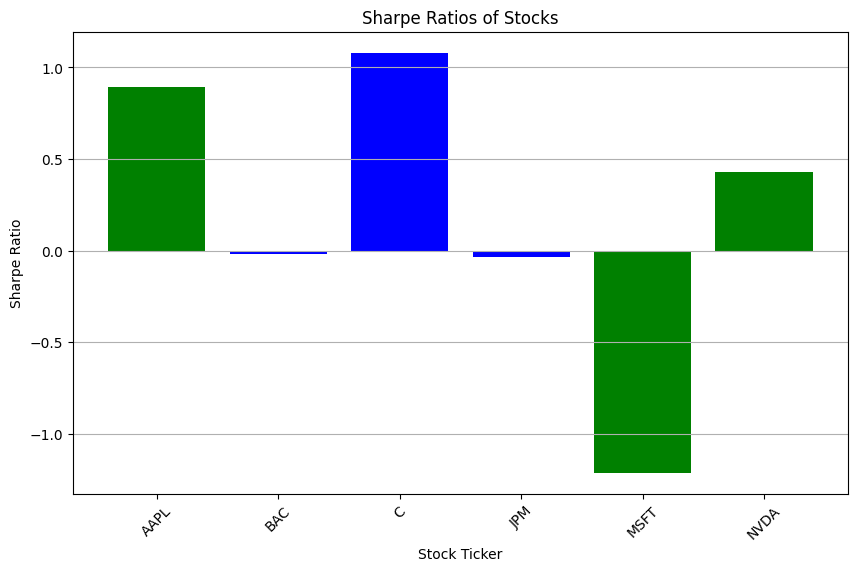

In [5]:
# ==========================================
# Execute the Crypto Heatmap Task
# ==========================================
# We give it a complex multi-step instruction.
task_prompt = """
1. Download daily closing data for 'NVDA', 'AAPL', 'MSFT', 'JPM', 'BAC' and 'C' for the last 180 days using yfinance.
2. Create a single DataFrame with these close prices.
3. Calculate the daily returns according to these close prices.
4. Calculate the Sharpe Ratio for each stock (Assume risk-free rate = 0, so simply Mean Daily Return / Std Dev of Daily Returns * sqrt(252))
5. Create a Bar Chart comparing the Sharpe Ratios of all 6 companies.
6. Color code the bars: Green for 'NVDA' ,'AAPL' and 'MSFT', Blue for 'JPM', 'BAC' and 'C'.
7. Save the chart as 'sharpe_comparison.png'
"""

print("🤖 Agent is coding... (Watch the 'Thought' process below)")
result = agent.run(task_prompt,stream=False)

In [6]:
print(result)

Chart saved successfully



📊 Displaying Generated Sharpe:


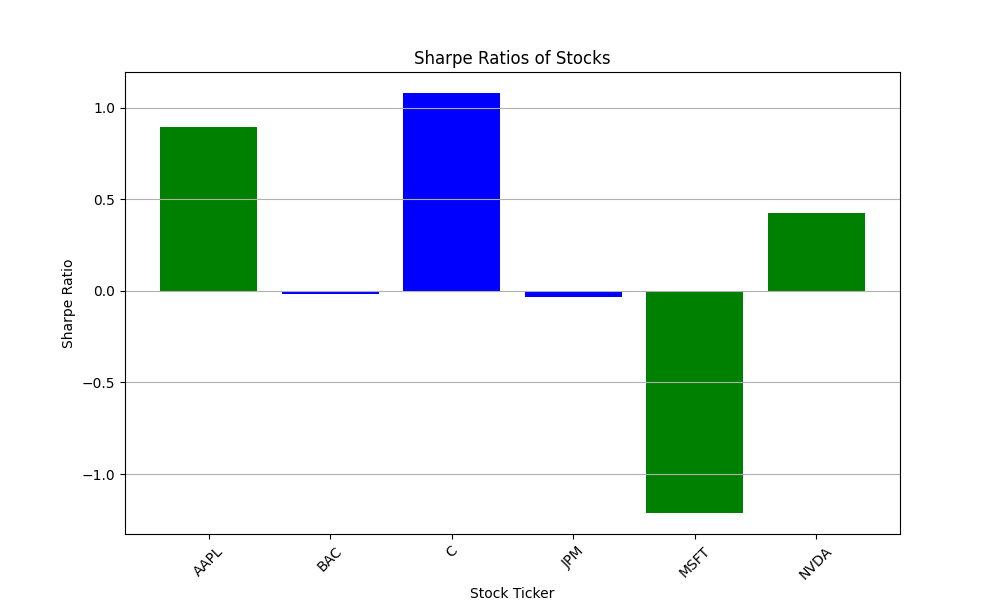

In [7]:
# ==========================================
# Display the Result
# ==========================================
import IPython
import os

if os.path.exists("sharpe_comparison.png"):
    print("\n📊 Displaying Generated Sharpe:")
    IPython.display.display(IPython.display.Image("sharpe_comparison.png"))
else:
    print("⚠️ No image file found. Check the agent's output logs above for errors.")